# Function 5 — Bayesian Optimization Campaign

This notebook documents the search for the input `(x1, x2, x3, x4)` that **maximizes** an
unknown ("black-box") 4D function whose yields span several orders of magnitude. A Gaussian
Process (GP) surrogate model is fit to the log-transformed observed data, and acquisition
functions (Expected Improvement, Upper Confidence Bound) are used to decide which point to
query next.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
import torch
import torch.nn as nn
import torch.optim as optim

## 2. Initial Data

In [2]:
X = np.load("function_5/data/initial_inputs.npy")
y = np.load("function_5/data/initial_outputs.npy")

Additional query rounds, appended as results came in:

In [3]:
X = np.append(X, [
    [0.220000, 0.628062, 0.879000, 0.879000],
    [0.000050, 0.000050, 0.066897, 0.999959],
    [0.189583, 0.886225, 0.999999, 0.999999],
    [0.931828, 0.990000, 0.990000, 0.990000],
    [0.000001, 0.000001, 0.999999, 0.999999],
    [0.189583, 0.990000, 0.628062, 0.990000],
    [0.604315, 0.130222, 0.279877, 0.236729],
    [0.990000, 0.990000, 0.990000, 0.990000],
    [0.189583, 0.130222, 0.990000, 0.990000],
    [0.999999, 0.000001, 0.999999, 0.999999],
    [0.000001, 0.000001, 0.999999, 0.999999],
    [0.960914, 0.990000, 0.990000, 0.990000],
    [0.999999, 0.999999, 0.999999, 0.999999],
    ], axis=0)

y = np.append(y, [
    554.0079824696209,
    190.72970845678554,
    3213.2161678630946,
    6986.351530669805,
    1616.6257474282386,
    1803.4228711413452,
    75.74587132062693,
    7915.738968949545,
    1460.073396444937,
    4440.480873839292,
    1616.6257474282386,
    7423.0491157208,
    8662.405001248297,
    ], axis=0)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Best observed y so far: {max(y)}")

X shape: (33, 4), y shape: (33,)
Best observed y so far: 8662.405001248297


Yields span several orders of magnitude, so we log-transform before modeling:

In [4]:
y_log = np.log1p(y)
current_best_log = np.max(y_log)

## 3. Gaussian Process Surrogate Model

`C(1.0)` lets the model scale the overall variance of the log-outputs; a `Matern` kernel with
one length-scale per input dimension lets each parameter affect the yield differently.
`alpha` adds a small amount of noise to the kernel diagonal for numerical stability, and
`normalize_y` helps the kernel optimizer converge.

In [5]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.1, 0.1, 0.1, 0.1],
    length_scale_bounds=(0.01, 10.0),
    nu=2.5
)

gp_model = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1,
    n_restarts_optimizer=40,
    normalize_y=True
)
gp_model.fit(X, y_log)

/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP.If `None` is passed,the kernel `ConstantKernel() * RBF()` is used as default.Note thatthe kernel hyperparameters are optimized during fittingunless the bounds are marked as `""fixed""`or the argument `optimizer` is set to `None`.","1**2 * Matern... 0.1], nu=2.5)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",40
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,kernel__k1,1**2
,kernel__k2,"Matern(length... 0.1], nu=2.5)"
,kernel__k1__constant_value,1.0
,kernel__k1__constant_value_bounds,"(0.001, ...)"
,kernel__k2__length_scale,"[0.1, 0.1, ...]"
,kernel__k2__length_scale_bounds,"(0.01, ...)"
,kernel__k2__nu,2.5


In [6]:
optimized_kernel = gp_model.kernel_
length_scales = optimized_kernel.get_params()['k2__length_scale']

print("--- Hyperparameter Check ---")
for i, ls in enumerate(length_scales):
    print(f"Parameter x{i+1} Length Scale: {ls:.4f}")

if np.any(np.isclose(length_scales, 0.01)) or np.any(np.isclose(length_scales, 10.0)):
    print("\nWARNING: One or more length scales are hitting the bounds. Consider widening 'length_scale_bounds'.")

--- Hyperparameter Check ---
Parameter x1 Length Scale: 10.0000
Parameter x2 Length Scale: 10.0000
Parameter x3 Length Scale: 1.1170
Parameter x4 Length Scale: 0.5737



## 4. Acquisition Functions

### Expected Improvement (EI)
`xi` is the exploration parameter. A numerically-safer variant that clips `sigma` away from
zero was also tried, with similar results.

In [7]:
def expected_improvement(x_test, xi=101):
    mu, sigma = gp_model.predict(x_test.reshape(1, -1), return_std=True)

    imp = mu - current_best_log - xi
    Z = imp / sigma if sigma > 0 else 0

    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

x_best = X[np.argmax(y)]
res = minimize(expected_improvement, x_best, bounds=[(0.01, 0.99)] * 4, method='L-BFGS-B')
next_point = res.x

print(f"Current Max Yield: {np.max(y_log)}")
print(f"Suggested Next Iteration Point (EI): {next_point}")

Current Max Yield: 9.066863111489765
Suggested Next Iteration Point (EI): [0.99 0.99 0.99 0.99]


### Upper Confidence Bound (UCB)
`kappa` controls the exploration/exploitation trade-off; the search is restarted from many
random points to avoid getting stuck in a local optimum of the acquisition surface itself.

In [8]:
def upper_confidence_bound(x_test, kappa=10):
    mu, sigma = gp_model.predict(x_test.reshape(1, -1), return_std=True)
    ucb = mu + kappa * sigma
    return -ucb

def get_next_candidate(bounds, kappa=2.576, n_restarts=10):
    best_x = None
    min_ucb = float('inf')

    for starting_point in np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_restarts, 4)):
        res = minimize(
            fun=upper_confidence_bound,
            x0=starting_point,
            args=(kappa,),
            bounds=bounds,
            method='L-BFGS-B'
        )

        if res.fun < min_ucb:
            min_ucb = res.fun
            best_x = res.x

    return best_x

bounds = np.array([[0, 1], [0, 1], [0, 1], [0, 1]])
next_x = get_next_candidate(bounds, kappa=5.0)  # high kappa to find peaks
next_point = next_x
print(f"Suggested Next Iteration Point (UCB): {next_x}")

Suggested Next Iteration Point (UCB): [1. 0. 1. 1.]


### Ranked Observations
A quick sanity check on where the current samples rank by (log) yield.

In [9]:
sorted_indices = np.argsort(y_log)
sorted_values = y_log[sorted_indices]

print(f"{'Rank':<6} | {'Orig Index':<10} | {'Value':<10}")
print("-" * 32)
for rank, idx in enumerate(sorted_indices):
    print(f"{rank:<6} | {idx:<10} | {sorted_values[rank]:.2f}")

Rank   | Orig Index | Value     
--------------------------------
0      | 2          | 0.11
1      | 3          | 1.65
2      | 8          | 2.29
3      | 19         | 2.40
4      | 1          | 2.96
5      | 10         | 3.24
6      | 16         | 3.40
7      | 17         | 3.83
8      | 6          | 4.07
9      | 12         | 4.17
10     | 11         | 4.18
11     | 0          | 4.18
12     | 26         | 4.34
13     | 5          | 4.37
14     | 13         | 4.39
15     | 7          | 4.71
16     | 21         | 5.26
17     | 9          | 5.46
18     | 4          | 5.56
19     | 14         | 5.88
20     | 18         | 6.07
21     | 20         | 6.32
22     | 15         | 6.99
23     | 28         | 7.29
24     | 30         | 7.39
25     | 24         | 7.39
26     | 25         | 7.50
27     | 22         | 8.08
28     | 29         | 8.40
29     | 23         | 8.85
30     | 31         | 8.91
31     | 27         | 8.98
32     | 32         | 9.07


## 5. Supplementary Analysis — Neural Network Saliency

Existing samples are manually labeled "positive" (high-yield, listed indices) or "negative",
and a small neural network is trained on that split as a sanity check on whether the
acquisition function's suggested `next_point` also looks promising from a classification
standpoint. This is exploratory and not part of the core GP/acquisition-function decision loop.

In [10]:
y_labels = np.zeros(len(X))
positive_indices = [24, 25, 23, 22, 15, 20, 18, 14, 4, 9, 21, 7]
y_labels[positive_indices] = 1

X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)
y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

nn_model_deep = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(nn_model_deep.parameters(), lr=0.01)
criterion = nn.BCELoss()

for _ in range(2000):
    optimizer.zero_grad()
    outputs = nn_model_deep(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

In [11]:
X_tensor.grad.zero_()
output = nn_model_deep(X_tensor)
output.backward(torch.ones_like(output))

deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")

Point | Deep Importance Score
 0    | 1.6131
 1    | 0.0002
 2    | 0.0000
 3    | 0.0000
 4    | 5.2579
 5    | 0.0024
 6    | 45.0896
 7    | 27.6340
 8    | 2.2293
 9    | 23.9855
10    | 0.0000
11    | 8.4358
12    | 0.0001
13    | 0.0000
14    | 0.0002
15    | 1.0662
16    | 0.0000
17    | 0.0000
18    | 0.0960
19    | 0.0000
20    | 1.8160
21    | 0.0000
22    | 0.7090
23    | 42.7985
24    | 20.4523
25    | 0.0003
26    | 0.0001
27    | 3.0864
28    | 19.7862
29    | 0.0023
30    | 20.4523
31    | 26.4025
32    | 2.5345


In [12]:
nn_model_deep.eval()
sample_input = torch.tensor(np.array([next_point]), dtype=torch.float32)

with torch.no_grad():
    prediction_prob = nn_model_deep(sample_input)

print(f"Next point: {next_point}")
print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Next point: [1. 0. 1. 1.]
Probability of being Positive (Class 1): 0.0000
Predicted Class: 0


## 6. Results Summary

Observed yield over the most recent iterations:

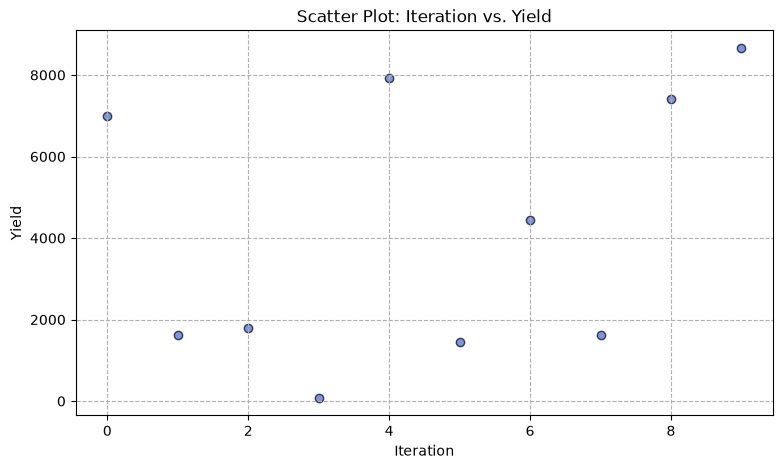

In [13]:
plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(0, 10)), y[-10:], color="royalblue", alpha=0.7, edgecolors="k"
)
plt.title("Scatter Plot: Iteration vs. Yield")
plt.xlabel("Iteration")
plt.ylabel("Yield")
plt.grid(True, linestyle="--", alpha=1)
plt.show()